# **CS224W - Colab 0**

Colab 0 **will not be graded**, so you don't need to hand in this notebook. That said, we highly recommend you to run this notebook, so you can get familiar with the basic concepts of graph mining and Graph Neural Networks.

In this Colab, we will introduce two packages, [NetworkX](https://networkx.org/documentation/stable/) and [PyTorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/).

For the PyTorch Geometric section, you don't need to understand all the details already. Concepts and implementations of graph neural network will be covered in future lectures and Colabs.

Please make a copy before you proceed.


# NetworkX Tutorial

NetworkX is one of the most frequently used Python packages to create, manipulate, and mine graphs.

Main parts of this tutorial are adapted from https://colab.research.google.com/github/jdwittenauer/ipython-notebooks/blob/master/notebooks/libraries/NetworkX.ipynb#scrollTo=zA1OO6huHeV6

## Setup

In [175]:
import networkx as nx
import matplotlib.pyplot as plt

## Graph
NetworkX provides several classes to store different types of graphs, such as directed and undirected graph. It also provides classes to create multigraphs (both directed and undirected).

For more information, please refer to [NetworkX graph types](https://networkx.org/documentation/stable/reference/classes/index.html).

In [176]:
# Create an undirected graph G
G = nx.Graph()
print(G.is_directed())

# Create a directed graph H

H = nx.DiGraph()
print(H.is_directed())

# Add graph level attribute
G.graph["Name"] = "Bar"
print(G.graph)

False
True
{'Name': 'Bar'}


## Node

Nodes (with attributes) can be easily added to NetworkX graphs.

In [177]:


# Add one node with node level attributes
G.add_node(0, feature=0, label=0)

node_0_attr = G.nodes[0]
print("Node 0 has the attributes {}".format(node_0_attr))
print(G)

Node 0 has the attributes {'feature': 0, 'label': 0}
Graph with 1 nodes and 0 edges


In [178]:
# Add multiple nodes with attributes
G.add_nodes_from([
  (1, {"feature": 1, "label": 1}),
  (2, {"feature": 2, "label": 2})
])

# Loop through all the nodes
# Set data=True will return node attributes
for node in G.nodes(data=True):
  print(node)

# Get number of nodes
num_nodes = G.number_of_nodes()
print("G has {} nodes".format(num_nodes))

(0, {'feature': 0, 'label': 0})
(1, {'feature': 1, 'label': 1})
(2, {'feature': 2, 'label': 2})
G has 3 nodes


## Edge

Similar to nodes, edges (with attributes) can also be easily added to NetworkX graphs.

In [179]:
# Add one edge with edge weight 0.5
G.add_edge(0, 1, weight=0.5)

# Get attributes of the edge (0, 1)
edge_0_1_attr = G.edges[(0, 1)]
print("Edge (0, 1) has the attributes {}".format(edge_0_1_attr))

Edge (0, 1) has the attributes {'weight': 0.5}


In [180]:
# Add multiple edges with edge weights
G.add_edges_from([
  (1, 2, {"weight": 0.3}),
  (2, 0, {"weight": 0.1})
])

# Loop through all the edges
# Here there is no data=True, so only the edge will be returned
for edge in G.edges():
  print(edge)

# Get number of edges
num_edges = G.number_of_edges()
print("G has {} edges".format(num_edges))

edge_0_1_attr = G.edges[(0, 1)]
edge_1_2_attr = G.edges[(1, 2)]
edge_2_0_attr = G.edges[(2, 0)]

print("Edge (0, 1) has the attributes {}".format(edge_0_1_attr))
print("Edge (1, 2) has the attributes {}".format(edge_1_2_attr))
print("Edge (2, 0) has the attributes {}".format(edge_2_0_attr))

(0, 1)
(0, 2)
(1, 2)
G has 3 edges
Edge (0, 1) has the attributes {'weight': 0.5}
Edge (1, 2) has the attributes {'weight': 0.3}
Edge (2, 0) has the attributes {'weight': 0.1}


## Visualization

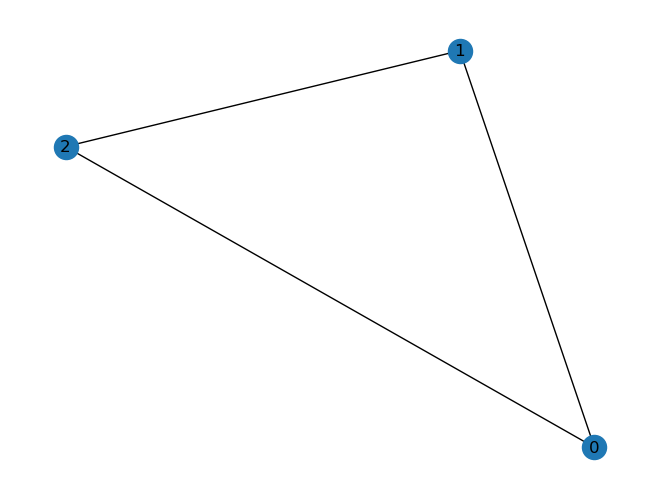

In [181]:
# Draw the graph

# Edge (0, 1) has the attributes {'weight': 0.5}
# Edge (1, 2) has the attributes {'weight': 0.3}
# Edge (2, 0) has the attributes {'weight': 0.1}

nx.draw(G, with_labels = True)

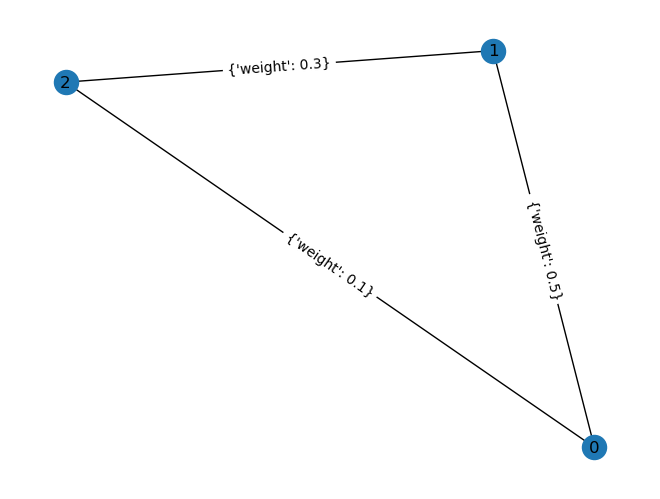

In [182]:
# Draw the graph with edge labels
pos = nx.spring_layout(G)  # Nodes coordinates
nx.draw(G, pos, with_labels=True)

edge_labels = {(u, v): d for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.show()

## Node Degree and Neighbor

In [183]:
node_id = 1

# Degree of node 1
print("Node {} has degree {}".format(node_id, G.degree[node_id]))

# Get neighbor of node 1
for neighbor in G.neighbors(node_id):
  print("Node {} has neighbor {}".format(node_id, neighbor))

Node 1 has degree 2
Node 1 has neighbor 0
Node 1 has neighbor 2


## Other Functionalities

NetworkX also provides plenty of useful methods to study graphs.

Here is an example to get [PageRank](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank.html#networkx.algorithms.link_analysis.pagerank_alg.pagerank) of nodes (we will talk about PageRank in one of the future lectures).

{0: 0.17857162031103999,
 1: 0.32142837968896,
 2: 0.32142837968896,
 3: 0.17857162031103999}

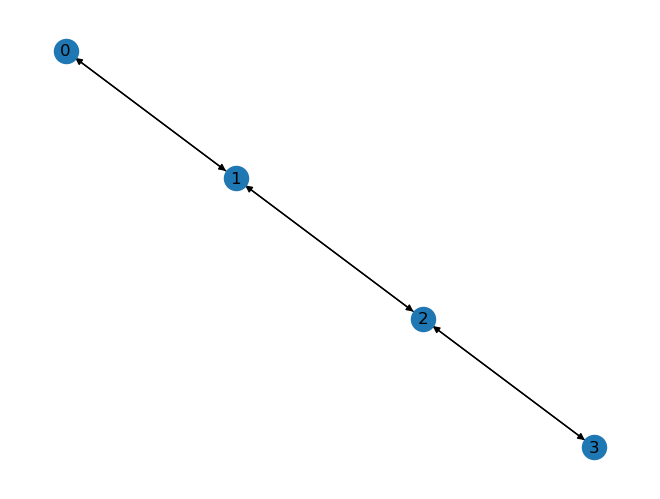

In [184]:
num_nodes = 4
# Create a new path like graph and change it to a directed graph
# DiGraph : Directed 
G = nx.DiGraph(nx.path_graph(num_nodes))
nx.draw(G, with_labels = True)

# Get the PageRank
pr = nx.pagerank(G, alpha=0.8)
pr

## Documentation

You can explore more NetworkX functions through its [documentation](https://networkx.org/documentation/stable/).

# PyTorch Geometric Tutorial

PyTorch Geometric (PyG) is an extension library for PyTorch. It provides useful primitives to develop Graph Deep Learning models, including various graph neural network layers and a large number of benchmark datasets.

Don't worry if you don't understand some concepts such as `GCNConv` -- we will cover all of them in the future lectures :)

This tutorial is adapted from https://colab.research.google.com/drive/1h3-vJGRVloF5zStxL5I0rSy4ZUPNsjy8?usp=sharing#scrollTo=ci-LpZWhRJoI by [Matthias Fey](https://rusty1s.github.io/#/)


In [185]:
# https://blog.naver.com/PostView.naver?blogId=dmsquf3015&logNo=222052080596&categoryNo=18&parentCategoryNo=0&viewDate=&currentPage=1&postListTopCurrentPage=1&from=search

import torch
print(torch.__version__)
print(torch.version.cuda)

2.5.1
None


In [186]:
import torch_geometric
print(torch_geometric.__version__)

2.7.0


## Visualization

In [187]:
# Helper function for visualization.
%matplotlib inline
import torch
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Visualization function for NX graph or PyTorch tensor

COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']  

def visualize(h, color):
    h = h.detach().cpu().numpy()
    y = color if isinstance(color, np.ndarray) else color.cpu().numpy()
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    for c in np.unique(y):
        mask = y == c
        ax.scatter(h[mask, 0], h[mask, 1], s=120, c=COLORS[c],
                   label=f'Community {c}', edgecolors='white', linewidths=0.5)
    
    ax.legend(fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    
    if epoch is not None and loss is not None:
        ax.set_title(f'Epoch {epoch} — Loss: {loss:.4f}', fontsize=12)
    
    plt.tight_layout()
    plt.show()

## Introduction

Recently, deep learning on graphs has emerged to one of the hottest research fields in the deep learning community.
Here, **Graph Neural Networks (GNNs)** aim to generalize classical deep learning concepts to irregular structured data (in contrast to images or texts) and to enable neural networks to reason about objects and their relations.

This tutorial will introduce you to some fundamental concepts regarding deep learning on graphs via Graph Neural Networks based on the **[PyTorch Geometric (PyG) library](https://github.com/rusty1s/pytorch_geometric)**.
PyTorch Geometric is an extension library to the popular deep learning framework [PyTorch](https://pytorch.org/), and consists of various methods and utilities to ease the implementation of Graph Neural Networks.

Following [Kipf et al. (2017)](https://arxiv.org/abs/1609.02907), let's dive into the world of GNNs by looking at a simple graph-structured example, the well-known [**Zachary's karate club network**](https://en.wikipedia.org/wiki/Zachary%27s_karate_club). This graph describes a social network of 34 members of a karate club and documents links between members who interacted outside the club. Here, we are interested in detecting communities that arise from the member's interaction.

The Zachary's Karate Club is the “hello world” of GNNs. It is a real-world social graph published by Wayne Zachary in 1977: he observed the interactions among 34 members of a college karate club over a two-year period. Following a conflict between the instructor (node 0) and the president (node 33), the club split into two factions—which presents a natural binary node classification problem.
In numbers: 34 nodes, 78 edges (undirected), 2 classes (instructor’s faction vs. president’s faction), no node features initially (one-hot encoding or identity embedding is often used).

Historically, Zachary has documented the conflict between two central figures: Mr. Hi (the instructor, node 0) and John A. (the president/administrator, node 33). The club eventually split into two factions, each following one of the two leaders.
The four communities are an algorithmic subdivision (by modularity) of these two factions. In sociological terms, this captures the following structure:
Mr. Hi’s (the instructor’s) faction is subdivided into two subgroups. On one side, the core group: the students closest to the instructor, who interact frequently with one another and directly with him (nodes highly connected to 0). On the other, the loyal periphery: members who followed the instructor during the split but whose daily interactions occurred more through intermediaries than through a direct link with Mr. Hi.
John A.’s (the president’s) faction is subdivided symmetrically. The administrative circle: members close to the president, involved in club management, highly interconnected with one another and with node 33. And the affiliated members: members who remained on the president’s side but whose social network is looser, often connected to the faction via only one or two links.
What is interesting is that this subdivision is not arbitrary—it reflects a classic sociological phenomenon: within a faction, there is always a gradient of loyalty/proximity between the center (the leaders and their inner circle) and the periphery (members who might have switched sides). The nodes on the boundary between communities are precisely those that Zachary identified as the hardest to predict during the split.
This is why moving from 2 to 4 classes is relevant for benchmarking a GNN: distinguishing the core from the periphery within the same faction requires capturing the graph’s fine-grained local structure, not just the overall partition.

## Dataset

PyTorch Geometric provides an easy access to the dataset via the [`torch_geometric.datasets`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets) subpackage:

In [188]:
# a social network of 34 members of a karate club
# documents links between members who interacted outside the club

# Here, we are interested in detecting communities that arise from the member's interaction.

from torch_geometric.datasets import KarateClub

### KarateClub dataset
# nodes : 34
# edges : 156
# features : 34
# classes : 4

dataset = KarateClub()
print(f'Dataset: {dataset}:')
print('======================')


print(f'Number of graphs: {len(dataset)}')

print(f'Number of features: {dataset.num_features}')

print(f'Number of classes: {dataset.num_classes}')



Dataset: KarateClub():
Number of graphs: 1
Number of features: 34
Number of classes: 4


In [189]:
print(dataset)
print(dataset[0])
print(len(dataset))

KarateClub()
Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
1


After initializing the [`KarateClub`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.KarateClub) dataset, we first can inspect some of its properties.
For example, we can see that this dataset holds exactly **one graph**, and that each node in this dataset is assigned a **34-dimensional feature vector** (which uniquely describes the members of the karate club).
Furthermore, the graph holds exactly **4 classes**, which represent the community each node belongs to.

Let's now look at the underlying graph in more detail:

In [190]:
data = dataset[0]  # Get the first graph object.

print(data)
print('==============================================================')

# Gather some statistics about the graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}')
print(f'Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}')
print(f'Contains isolated nodes: {data.has_isolated_nodes()}')
print(f'Contains self-loops: {data.has_isolated_nodes()}')
print(f'Is undirected: {data.is_undirected()}')

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
Number of nodes: 34
Number of edges: 156
Average node degree: 4.59
Number of training nodes: 4
Training node label rate: 0.12
Contains isolated nodes: False
Contains self-loops: False
Is undirected: True


## Data

Each graph in PyTorch Geometric is represented by a single [`Data`](https://pytorch-geometric.readthedocs.io/en/latest/modules/data.html#torch_geometric.data.Data) object, which holds all the information to describe its graph representation.
We can print the data object anytime via `print(data)` to receive a short summary about its attributes and their shapes:
```
Data(edge_index=[2, 156], x=[34, 34], y=[34], train_mask=[34])
```
We can see that this `data` object holds 4 attributes:
(1) The `edge_index` property holds the information about the **graph connectivity**, *i.e.*, a tuple of source and destination node indices for each edge.
PyG further refers to (2) **node features** as `x` (each of the 34 nodes is assigned a 34-dim feature vector), and to (3) **node labels** as `y` (each node is assigned to exactly one class).
(4) There also exists an additional attribute called `train_mask`, which describes for which nodes we already know their community assigments.
In total, we are only aware of the ground-truth labels of 4 nodes (one for each community), and the task is to infer the community assignment for the remaining nodes.

The `data` object also provides some **utility functions** to infer some basic properties of the underlying graph.
For example, we can easily infer whether there exists isolated nodes in the graph (*i.e.* there exists no edge to any node), whether the graph contains self-loops (*i.e.*, $(v, v) \in \mathcal{E}$), or whether the graph is undirected (*i.e.*, for each edge $(v, w) \in \mathcal{E}$ there also exists the edge $(w, v) \in \mathcal{E}$).

In [191]:
edge_index = data.edge_index

print(edge_index.t())

tensor([[ 0,  1],
        [ 0,  2],
        [ 0,  3],
        [ 0,  4],
        [ 0,  5],
        [ 0,  6],
        [ 0,  7],
        [ 0,  8],
        [ 0, 10],
        [ 0, 11],
        [ 0, 12],
        [ 0, 13],
        [ 0, 17],
        [ 0, 19],
        [ 0, 21],
        [ 0, 31],
        [ 1,  0],
        [ 1,  2],
        [ 1,  3],
        [ 1,  7],
        [ 1, 13],
        [ 1, 17],
        [ 1, 19],
        [ 1, 21],
        [ 1, 30],
        [ 2,  0],
        [ 2,  1],
        [ 2,  3],
        [ 2,  7],
        [ 2,  8],
        [ 2,  9],
        [ 2, 13],
        [ 2, 27],
        [ 2, 28],
        [ 2, 32],
        [ 3,  0],
        [ 3,  1],
        [ 3,  2],
        [ 3,  7],
        [ 3, 12],
        [ 3, 13],
        [ 4,  0],
        [ 4,  6],
        [ 4, 10],
        [ 5,  0],
        [ 5,  6],
        [ 5, 10],
        [ 5, 16],
        [ 6,  0],
        [ 6,  4],
        [ 6,  5],
        [ 6, 16],
        [ 7,  0],
        [ 7,  1],
        [ 7,  2],
        [ 

In [192]:
print(data.x)

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])


In [193]:
print(len(data.x))

34


## Edge Index

By printing `edge_index`, we can further understand how PyG represents graph connectivity internally.
We can see that for each edge, `edge_index` holds a tuple of two node indices, where the first value describes the node index of the source node and the second value describes the node index of the destination node of an edge.

This representation is known as the **COO format (coordinate format)** commonly used for representing sparse matrices.
Instead of holding the adjacency information in a dense representation $\mathbf{A} \in \{ 0, 1 \}^{|\mathcal{V}| \times |\mathcal{V}|}$, PyG represents graphs sparsely, which refers to only holding the coordinates/values for which entries in $\mathbf{A}$ are non-zero.

We can further visualize the graph by converting it to the `networkx` library format, which implements, in addition to graph manipulation functionalities, powerful tools for visualization:

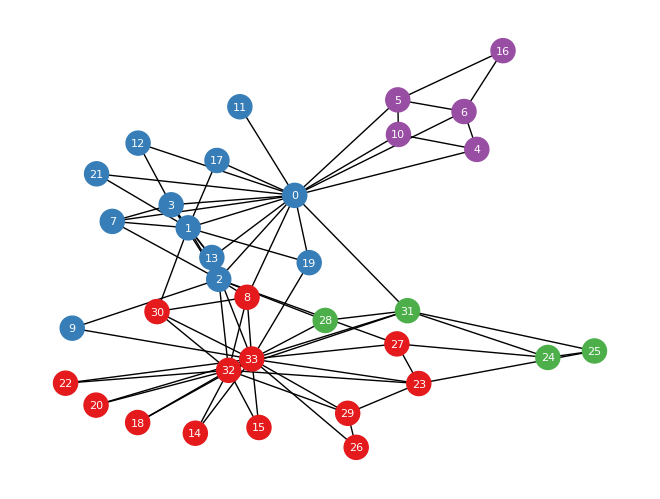

Mr. Hi, instructor node: 0 and Mr. John, president node: 33
Train nodes: [0, 4, 8, 24]


In [233]:
G = to_networkx(data, to_undirected=True)

pos = nx.spring_layout(G, seed=42)
colors = plt.cm.Set1(data.y.numpy())

nx.draw(G, pos, node_color=colors, with_labels=True,
        node_size=300, font_size=8, font_color="white")
plt.show()

print("Mr. Hi, instructor node: 0 and Mr. John, president node: 33")
print("Train nodes:", data.train_mask.nonzero(as_tuple=True)[0].tolist())

In [195]:
print(dataset.num_features)
print(dataset.num_classes)

34
4


In [196]:
print(len(data.edge_index))
print(data.edge_index)

2
tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,
          3,  3,  3,  3,  3,  4,  4,  4,  5,  5,  5,  5,  6,  6,  6,  6,  7,  7,
          7,  7,  8,  8,  8,  8,  8,  9,  9, 10, 10, 10, 11, 12, 12, 13, 13, 13,
         13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 19, 20, 20, 21,
         21, 22, 22, 23, 23, 23, 23, 23, 24, 24, 24, 25, 25, 25, 26, 26, 27, 27,
         27, 27, 28, 28, 28, 29, 29, 29, 29, 30, 30, 30, 30, 31, 31, 31, 31, 31,
         31, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 33, 33, 33, 33, 33,
         33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33],
        [ 1,  2,  3,  4,  5,  6,  7,  8, 10, 11, 12, 13, 17, 19, 21, 31,  0,  2,
          3,  7, 13, 17, 19, 21, 30,  0,  1,  3,  7,  8,  9, 13, 27, 28, 32,  0,
          1,  2,  7, 12, 13,  0,  6, 10,  0,  6, 10, 16,  0,  4,  5, 16,  0,  1,
          2,  3,  0,  2, 30, 32, 33,  2, 33,  0, 

In [197]:
print(data.edge_index.T)

tensor([[ 0,  1],
        [ 0,  2],
        [ 0,  3],
        [ 0,  4],
        [ 0,  5],
        [ 0,  6],
        [ 0,  7],
        [ 0,  8],
        [ 0, 10],
        [ 0, 11],
        [ 0, 12],
        [ 0, 13],
        [ 0, 17],
        [ 0, 19],
        [ 0, 21],
        [ 0, 31],
        [ 1,  0],
        [ 1,  2],
        [ 1,  3],
        [ 1,  7],
        [ 1, 13],
        [ 1, 17],
        [ 1, 19],
        [ 1, 21],
        [ 1, 30],
        [ 2,  0],
        [ 2,  1],
        [ 2,  3],
        [ 2,  7],
        [ 2,  8],
        [ 2,  9],
        [ 2, 13],
        [ 2, 27],
        [ 2, 28],
        [ 2, 32],
        [ 3,  0],
        [ 3,  1],
        [ 3,  2],
        [ 3,  7],
        [ 3, 12],
        [ 3, 13],
        [ 4,  0],
        [ 4,  6],
        [ 4, 10],
        [ 5,  0],
        [ 5,  6],
        [ 5, 10],
        [ 5, 16],
        [ 6,  0],
        [ 6,  4],
        [ 6,  5],
        [ 6, 16],
        [ 7,  0],
        [ 7,  1],
        [ 7,  2],
        [ 

In [198]:
print(data.edge_index.T.shape)

torch.Size([156, 2])


## Implementing Graph Neural Networks

After learning about PyG's data handling, it's time to implement our first Graph Neural Network!

For this, we will use one of the most simple GNN operators, the **GCN layer** ([Kipf et al. (2017)](https://arxiv.org/abs/1609.02907)).

PyG implements this layer via [`GCNConv`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.conv.GCNConv), which can be executed by passing in the node feature representation `x` and the COO graph connectivity representation `edge_index`.

With this, we are ready to create our first Graph Neural Network by defining our network architecture in a `torch.nn.Module` class:

In [222]:
import torch
from torch.nn import Linear
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(dataset.num_features, 16)  # 32 → 16
        self.conv2 = GCNConv(16, 8)                      # 16 → 8
        self.classifier = Linear(8, dataset.num_classes)
        self.dropout = torch.nn.Dropout(0.3)              

    def forward(self, x, edge_index):
        h = torch.relu(self.conv1(x, edge_index))
        h = self.dropout(h)
        h = self.conv2(h, edge_index)
        out = self.classifier(h)
        return out, h

Here, we first initialize all of our building blocks in `__init__` and define the computation flow of our network in `forward`.
We first define and stack **three graph convolution layers**, which corresponds to aggregating 3-hop neighborhood information around each node (all nodes up to 3 "hops" away).
In addition, the `GCNConv` layers reduce the node feature dimensionality to $2$, *i.e.*, $34 \rightarrow 4 \rightarrow 4 \rightarrow 2$. Each `GCNConv` layer is enhanced by a [tanh](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html?highlight=tanh#torch.nn.Tanh) non-linearity.

After that, we apply a single linear transformation ([`torch.nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html?highlight=linear#torch.nn.Linear)) that acts as a classifier to map our nodes to 1 out of the 4 classes/communities.

We return both the output of the final classifier as well as the final node embeddings produced by our GNN.
We proceed to initialize our final model via `GCN()`, and printing our model produces a summary of all its used sub-modules.

The three GCNConv layers form a progressively narrowing encoder that compresses node information through message passing:
- Layer 1 — GCNConv(34, 4): Takes the 34-dimensional input features (one-hot identity of each node) and projects them into a 4-dimensional space. At this stage, each node aggregates features from its direct neighbors (1-hop). The tanh activation introduces non-linearity so the model can learn more than a simple linear combination.
- Layer 2 — GCNConv(4, 4): Keeps the same dimensionality (4→4) but expands the receptive field to 2-hop neighborhoods. Now each node's representation encodes information from neighbors of neighbors. This is where the model starts capturing community-level structure rather than just local connectivity.
- Layer 3 — GCNConv(4, 2): Compresses to 2 dimensions, reaching 3-hop neighborhoods. This bottleneck forces the model to distill the most discriminative structural information into a 2D embedding h — which is why you can directly scatter-plot it and see clusters.
- The final Linear(2, 4) classifier then maps these 2D embeddings to 4 class logits. It's deliberately separated from the GCN layers so you can inspect the intermediate embedding h before classification — that's why forward returns both out and h.
The key insight: stacking k GCN layers gives each node a k-hop receptive field. With 3 layers and a graph diameter of ~5 for the karate club, most nodes can "see" almost the entire graph, which is sufficient (and borderline over-smoothing territory for larger graphs).

Embedding shape: [34, 8]


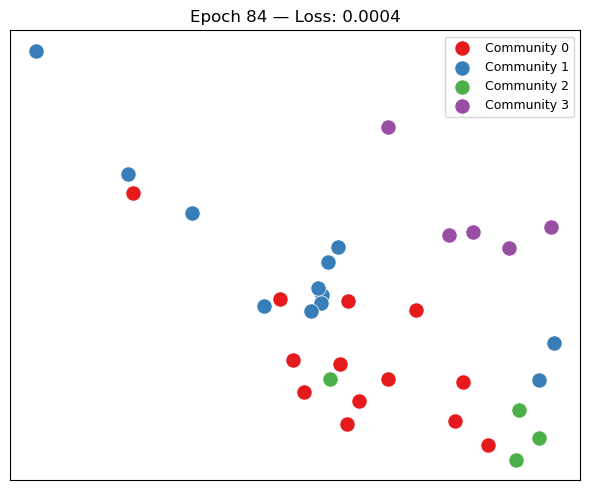

In [232]:
model = GCN()


_, h = model(data.x, data.edge_index)
print(f'Embedding shape: {list(h.shape)}')

visualize(h, color=data.y,)

Remarkably, even before training the weights of our model, the model produces an embedding of nodes that closely resembles the community-structure of the graph.
Nodes of the same color (community) are already closely clustered together in the embedding space, although the weights of our model are initialized **completely at random** and we have not yet performed any training so far!
This leads to the conclusion that GNNs introduce a strong inductive bias, leading to similar embeddings for nodes that are close to each other in the input graph.

### Training on the Karate Club Network

But can we do better? Let's look at an example on how to train our network parameters based on the knowledge of the community assignments of 4 nodes in the graph (one for each community):

Since everything in our model is differentiable and parameterized, we can add some labels, train the model and observe how the embeddings react.
Here, we make use of a semi-supervised or transductive learning procedure: We simply train against one node per class, but are allowed to make use of the complete input graph data.

Training our model is very similar to any other PyTorch model.
In addition to defining our network architecture, we define a loss critertion (here, [`CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)) and initialize a stochastic gradient optimizer (here, [`Adam`](https://pytorch.org/docs/stable/optim.html?highlight=adam#torch.optim.Adam)).
After that, we perform multiple rounds of optimization, where each round consists of a forward and backward pass to compute the gradients of our model parameters w.r.t. to the loss derived from the forward pass.
If you are not new to PyTorch, this scheme should appear familar to you. 
Otherwise, the PyTorch docs provide [a good introduction on how to train a neural network in PyTorch](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html#define-a-loss-function-and-optimizer).

Note that our semi-supervised learning scenario is achieved by the following line:
```
loss = criterion(out[data.train_mask], data.y[data.train_mask])
```
While we compute node embeddings for all of our nodes, we **only make use of the training nodes for computing the loss**.
Here, this is implemented by filtering the output of the classifier `out` and ground-truth labels `data.y` to only contain the nodes in the `train_mask`.

Let us now start training and see how our node embeddings evolve over time (best experienced by explicitely running the code):

Early stopping at epoch 84
Best Test Acc: 0.8333 at epoch 34


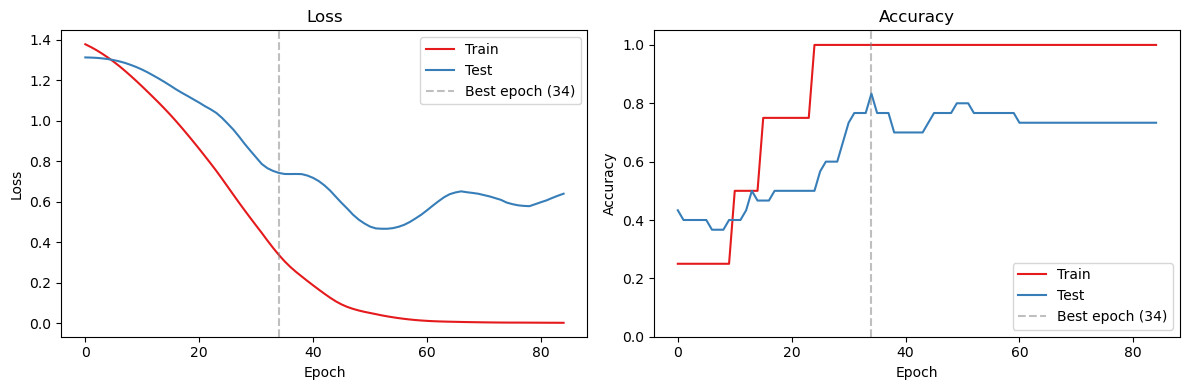

In [230]:
model = GCN()
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

test_mask = ~data.train_mask

train_losses, test_losses = [], []
train_accs, test_accs = [], []

def train(data):
    model.train()
    optimizer.zero_grad()
    out, h = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        out, h = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)

        t_loss = criterion(out[data.train_mask], data.y[data.train_mask]).item()
        t_acc = (pred[data.train_mask] == data.y[data.train_mask]).sum().item() / data.train_mask.sum().item()

        v_loss = criterion(out[test_mask], data.y[test_mask]).item()
        v_acc = (pred[test_mask] == data.y[test_mask]).sum().item() / test_mask.sum().item()

    return t_loss, t_acc, v_loss, v_acc, h

best_acc = 0
best_state = None
patience = 50
patience_counter = 0

for epoch in range(1001):
    t_loss, t_acc, v_loss, v_acc, h = train(data)
    train_losses.append(t_loss)
    test_losses.append(v_loss)
    train_accs.append(t_acc)
    test_accs.append(v_acc)

    if v_acc > best_acc:
        best_acc = v_acc
        best_epoch = epoch
        best_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f'Early stopping at epoch {epoch}')
        break

model.load_state_dict(best_state)
print(f'Best Test Acc: {best_acc:.4f} at epoch {best_epoch}')

# --- Courbes ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, color='#e41a1c', label='Train')
ax1.plot(test_losses, color='#377eb8', label='Test')
ax1.axvline(best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'Best epoch ({best_epoch})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.legend()

ax2.plot(train_accs, color='#e41a1c', label='Train')
ax2.plot(test_accs, color='#377eb8', label='Test')
ax2.axvline(best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'Best epoch ({best_epoch})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy')
ax2.set_ylim(0, 1.05)
ax2.legend()

plt.tight_layout()
plt.show()

As one can see, our 3-layer GCN model manages to linearly separating the communities and classifying most of the nodes correctly.

Furthermore, we did this all with a few lines of code, thanks to the PyTorch Geometric library which helped us out with data handling and GNN implementations.


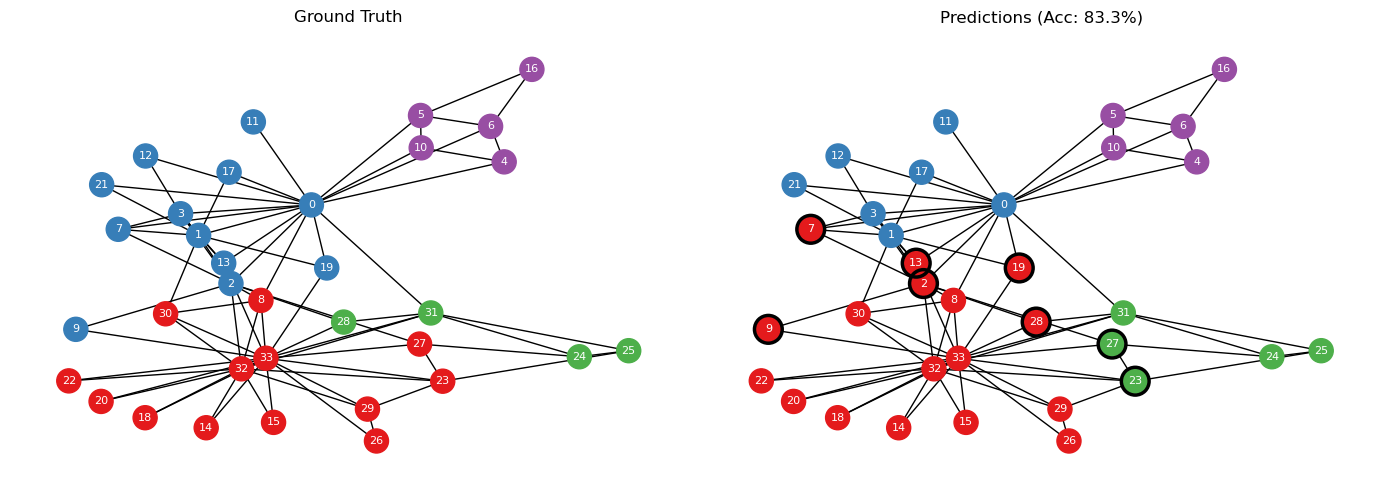

Wrong nodes: [2, 7, 9, 13, 19, 23, 27, 28]
  Node 2: true=1, predicted=0
  Node 7: true=1, predicted=0
  Node 9: true=1, predicted=0
  Node 13: true=1, predicted=0
  Node 19: true=1, predicted=0
  Node 23: true=0, predicted=2
  Node 27: true=0, predicted=2
  Node 28: true=2, predicted=0


In [229]:
# load the best model and evaluate on the test set
model.load_state_dict(best_state)
model.eval()

with torch.no_grad():
    out, h = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

G = to_networkx(data, to_undirected=True)
pos = nx.spring_layout(G, seed=42)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

# Vérité terrain
true_colors = [COLORS[c] for c in data.y.numpy()]
nx.draw(G, pos, node_color=true_colors, with_labels=True,
        node_size=300, font_size=8, font_color='white', ax=ax1)
ax1.set_title('Ground Truth')


pred_colors = [COLORS[c] for c in pred.numpy()]
nx.draw(G, pos, node_color=pred_colors, with_labels=True,
        node_size=300, font_size=8, font_color='white', ax=ax2)
ax2.set_title(f'Predictions (Acc: {best_acc:.1%})')

# Marquer les erreurs
wrong = (pred != data.y).numpy()
wrong_nodes = [i for i, w in enumerate(wrong) if w]
nx.draw_networkx_nodes(G, pos, nodelist=wrong_nodes,
                       node_size=400, node_color='none',
                       edgecolors='black', linewidths=2.5, ax=ax2)

plt.tight_layout()
plt.show()

print(f'Wrong nodes: {wrong_nodes}')
for n in wrong_nodes:
    print(f'  Node {n}: true={data.y[n].item()}, predicted={pred[n].item()}')

## Documentation



You can explore more PyG functions through its [documentation](https://pytorch-geometric.readthedocs.io/en/latest/).